In [6]:
# !pip install pandas 
# !pip install openpyxl
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn


# Libraries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFE

# EDA

In [8]:
data = pd.read_excel("C:/Users/dbastola2022/OneDrive - Florida Atlantic University/Academics/Research/NDHS/Dataset/Children's Recode/Children Recode.xlsx")
data.head()

,caseid,bidx,v000,v001,v002,v003,v004,v005,v006,v007,...,s604c,s607ea,s607eb,s607ec,s607ed,s607ex,s607f,s607g,s615f,s631o
0,1 1 2,1,NP8,1,1,2,1,916093,10,2078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,1 8 2,1,NP8,1,8,2,1,916093,10,2078,...,0.0,0.0,1.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0
2,1 8 2,2,NP8,1,8,2,1,916093,10,2078,...,NaN,0.0,1.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0
3,1 9 3,1,NP8,1,9,3,1,916093,10,2078,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0
4,1 19 1,1,NP8,1,19,1,1,916093,10,2078,...,0.0,1.0,1.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN


In [9]:
df1 = data.copy()
df1 = df1[['b19', 'v106', 'v190', 'v102', 'v101', 'v445', 'b11', 'v137', 'v130', 'v131', 'm19', 'b4', 'm4', 'v012', 'v729', 'v714', 'v481', 'hw71', 'hw70']]
df1.rename(columns={'b19': 'Child_age', 'v106':'Mother_education', 'v190':'Wealth_index', 'v102':'Place_residence', 'v101':'Region', 'v445':'BMI', 'b11':'Birth_interval', 'v137':'Children_under5', 'v130':'Religion', 'v131':'Ethnicity', 'm19':'Birth_weight', 'b4':'Child_sex', 'm4':'Breastfeeding_duration', 'v012':'Mother_age', 'v729':'Father_education', 'v714':'Mother_working', 'v481':'Health_insurance', 'hw71':'Status'}, inplace=True)
df1.head()

,Child_age,Mother_education,Wealth_index,Place_residence,Region,BMI,Birth_interval,Children_under5,Religion,Ethnicity,Birth_weight,Child_sex,Breastfeeding_duration,Mother_age,Father_education,Mother_working,Health_insurance,Status,hw70
0,41,1,1,2,1,NaN,36.0,1,4,8,NaN,2,NaN,29,2.0,1,0,NaN,NaN
1,28,1,1,2,1,NaN,13.0,2,1,2,9996.0,2,95.0,33,1.0,0,0,NaN,NaN
2,42,1,1,2,1,NaN,NaN,2,1,2,NaN,2,NaN,33,1.0,0,0,NaN,NaN
3,17,1,1,2,1,2200.0,207.0,1,1,2,3100.0,2,95.0,34,3.0,0,0,-65.0,-111.0
4,40,2,2,2,1,2510.0,19.0,2,4,8,NaN,1,NaN,26,2.0,1,0,-185.0,-311.0


In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Child_age               5372 non-null   int64  
 1   Mother_education        5372 non-null   int64  
 2   Wealth_index            5372 non-null   int64  
 3   Place_residence         5372 non-null   int64  
 4   Region                  5372 non-null   int64  
 5   BMI                     2736 non-null   float64
 6   Birth_interval          3172 non-null   float64
 7   Children_under5         5372 non-null   int64  
 8   Religion                5372 non-null   int64  
 9   Ethnicity               5372 non-null   int64  
 10  Birth_weight            3177 non-null   float64
 11  Child_sex               5372 non-null   int64  
 12  Breastfeeding_duration  3177 non-null   float64
 13  Mother_age              5372 non-null   int64  
 14  Father_education        5322 non-null   

In [11]:
df1.shape

(5372, 19)

Nominal variable are required to use one-hot encoding which i'll do later.

In [32]:
# df1.describe()

In [13]:
# df1['Mother_education'].plot.hist()

# Data preprocessing

**Drop rows with encoded values**

In [14]:
df2 = df1.copy()
df2.drop(index = 3251, inplace=True) # BMI 9998.0
df2.drop(index = [658,730, 4417], inplace = True) # Religion 96
df2.drop(index = [1369, 602, 603], inplace=True) # Ethnicity 96
df2 = df2[~df2['Birth_weight'].isin([9998, 9996])] # Birth_weight 9998 or 9996
df2.drop(index = 1651, inplace=True) # Status 9998

In [15]:
# df2.sort_values(by = "Status", ascending=False)

**Drop column to get maximum possible observations**

In [16]:
df3 = df2.drop(columns= ['hw70', 'Birth_interval', 'Birth_weight', 'Breastfeeding_duration'])
df3.isna().sum()

Child_age              0
Mother_education       0
Wealth_index           0
Place_residence        0
Region                 0
BMI                 2313
Children_under5        0
Religion               0
Ethnicity              0
Child_sex              0
Mother_age             0
Father_education      46
Mother_working         0
Health_insurance       0
Status              2432
dtype: int64

*Drop all remaining missing values*

In [17]:
df4=df3.dropna().copy()
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2253 entries, 3 to 5369
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Child_age         2253 non-null   int64  
 1   Mother_education  2253 non-null   int64  
 2   Wealth_index      2253 non-null   int64  
 3   Place_residence   2253 non-null   int64  
 4   Region            2253 non-null   int64  
 5   BMI               2253 non-null   float64
 6   Children_under5   2253 non-null   int64  
 7   Religion          2253 non-null   int64  
 8   Ethnicity         2253 non-null   int64  
 9   Child_sex         2253 non-null   int64  
 10  Mother_age        2253 non-null   int64  
 11  Father_education  2253 non-null   float64
 12  Mother_working    2253 non-null   int64  
 13  Health_insurance  2253 non-null   int64  
 14  Status            2253 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 281.6 KB


**WAZ score range**

In [18]:
# Indicator	Normal Range (Z-Score)	Description
# Weight-for-Age	-2 ≤ WAZ ≤ +2	Normal weight for the child's age.
# Height-for-Age	-2 ≤ HAZ ≤ +2	Normal height for the child's age.
# Weight-for-Height	-2 ≤ WHZ ≤ +2	Normal weight relative to the child's height.
# BMI-for-Age	-2 ≤ BAZ ≤ +2	Normal body mass index relative to age.

In [19]:
df4['BMI'] = df4['BMI']/100
df4['Status'] = df4['Status']/100
df4['Status'] = [0 if -2 <= val <= 2 else 1 for val in df4['Status']]
df4.head()

,Child_age,Mother_education,Wealth_index,Place_residence,Region,BMI,Children_under5,Religion,Ethnicity,Child_sex,Mother_age,Father_education,Mother_working,Health_insurance,Status
3,17,1,1,2,1,22.00,1,1,2,2,34,3.0,0,0,0
4,40,2,2,2,1,25.10,2,4,8,1,26,2.0,1,0,0
5,59,2,2,2,1,25.10,2,4,8,2,26,2.0,1,0,0
11,55,2,2,2,1,21.53,1,4,8,2,28,1.0,1,0,1
14,14,1,1,2,1,28.03,1,4,8,1,26,0.0,1,0,0


### One-hot encoding to nominal variables

In [20]:
# df4_nominal = ['Region', 'Religion', 'Ethnicity']
# df5 = pd.get_dummies(df4, columns = df4_nominal)
# df5 = df5.map(lambda x:1 if x is True else (0 if x is False else x ))
# df5.head()

In [21]:
# # Train test split
# X = df5.iloc[:, :-1]
# y = df5.iloc[:, -1]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Initialize and train the logistic regression model
# model = LogisticRegression(max_iter=300)
# model.fit(X_train, y_train)

# # Evaluate the model
# score = model.score(X_test, y_test)
# score

## Visual interpretation 

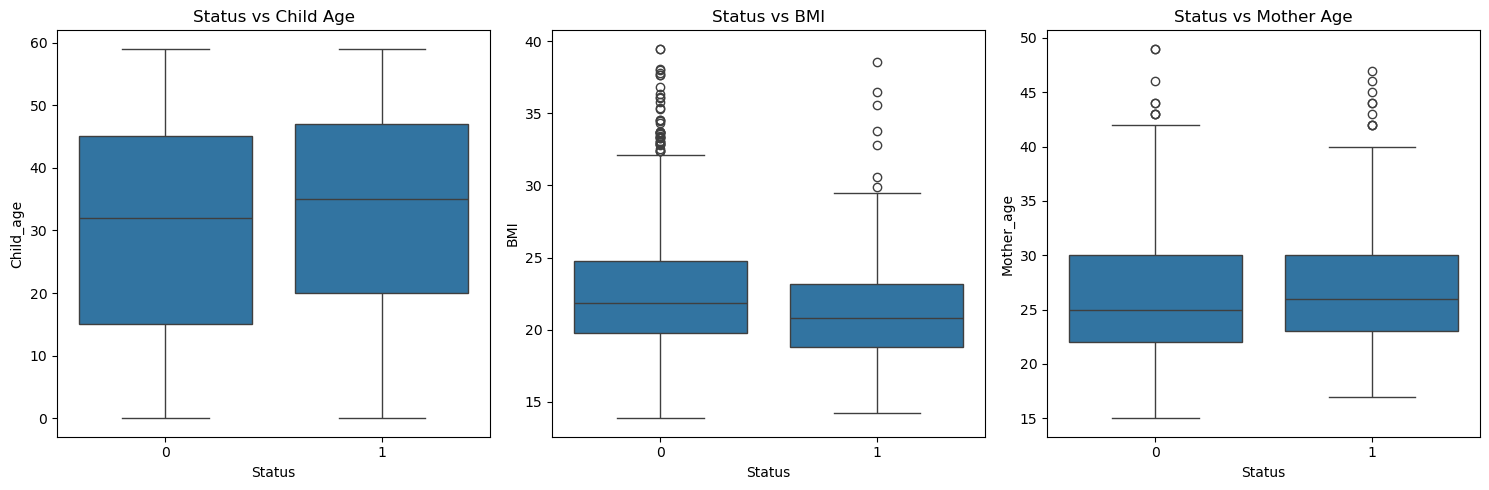

<Figure size 640x480 with 0 Axes>

In [22]:
# Continuous Variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

sns.boxplot(x='Status', y='Child_age', data=df4, ax=axes[0])
axes[0].set_title('Status vs Child Age')

sns.boxplot(x='Status', y='BMI', data=df4, ax=axes[1])
axes[1].set_title('Status vs BMI')

sns.boxplot(x='Status', y='Mother_age', data=df4, ax=axes[2])
axes[2].set_title('Status vs Mother Age')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


## Model

In [23]:
df = df4
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [24]:
# Initialize and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\dbastola2022\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [25]:
model.score(X_test, y_test)

0.8270509977827051

### Hptermeter tunning & Cross validation 

In [26]:
# Define the hyperparameters and their values
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 300]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

# Evaluate the best model
best_model = grid_search.best_estimator_
score = best_model.score(X_test, y_test)

# Cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

print("Best parameters found: ", best_params)
print("Cross-validation scores: ", cv_scores)
print("Model accuracy: ", score)

Best parameters found:  {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Cross-validation scores:  [0.81596452 0.81374723 0.81374723 0.81555556 0.81555556]
Model accuracy:  0.8270509977827051


### Feature selection

In [27]:
# Recursive Feature Elimination (RFE)
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X_train, y_train)

# Get the selected features
selected_features_rfe = X.columns[rfe.support_]
print("Selected features by RFE: ", selected_features_rfe)

# Train the model with selected features
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)
model.fit(X_train_rfe, y_train)

# Evaluate the model
score = model.score(X_test_rfe, y_test)
print("Model accuracy with RFE: ", score)

c:\Users\dbastola2022\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\dbastola2022\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

Selected features by RFE:  Index(['Mother_education', 'BMI', 'Religion', 'Child_sex', 'Health_insurance'], dtype='object')
Model accuracy with RFE:  0.8270509977827051
